<font color = green >

# Natural Language Toolkit (NLTK)

</font>

<font color = green >

## 1. NLTK Corpora

</font>

[Accessing Text Corpora and Lexical Resources](https://www.nltk.org/book/ch02.html)

In [81]:
import nltk

#### Download necessary corpus 

In [82]:
nltk.download('gutenberg')

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

#### Review content of loaded corpus 

<font color = green >

### 1.1 Gutenberg corpus

</font>

NLTK includes a small selection of texts from the Project Gutenberg electronic text archive, which contains some 25,000 free electronic books, hosted at http://www.gutenberg.org/.


In [83]:
from nltk.corpus import gutenberg
gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

#### Choose target file id and review raw text

In [84]:
moby_dick_id= gutenberg.fileids()[-6]
print ('moby_dick_id=', moby_dick_id)
type(gutenberg.raw(moby_dick_id))
print(gutenberg.raw(moby_dick_id)[:400])

moby_dick_id= melville-moby_dick.txt
[Moby Dick by Herman Melville 1851]


ETYMOLOGY.

(Supplied by a Late Consumptive Usher to a Grammar School)

The pale Usher--threadbare in coat, heart, body, and brain; I see him
now.  He was ever dusting his old lexicons and grammars, with a queer
handkerchief, mockingly embellished with all the gay flags of all the
known nations of the world.  He loved to dust his old grammars; it
so


#### Review tokenized text

In [85]:
md_text= gutenberg.words(moby_dick_id)
print ('Words number = {:,}'.format(len(md_text))) 
print ('Unique words number = {:,}\n'.format(len(set(md_text)))) 
print (md_text[:30])


Words number = 260,819
Unique words number = 19,317

['[', 'Moby', 'Dick', 'by', 'Herman', 'Melville', '1851', ']', 'ETYMOLOGY', '.', '(', 'Supplied', 'by', 'a', 'Late', 'Consumptive', 'Usher', 'to', 'a', 'Grammar', 'School', ')', 'The', 'pale', 'Usher', '--', 'threadbare', 'in', 'coat', ',']


#### Review sentences

In [86]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [87]:
md_sent = gutenberg.sents(moby_dick_id)
len(md_sent)
md_sent[:3]

[['[', 'Moby', 'Dick', 'by', 'Herman', 'Melville', '1851', ']'],
 ['ETYMOLOGY', '.'],
 ['(',
  'Supplied',
  'by',
  'a',
  'Late',
  'Consumptive',
  'Usher',
  'to',
  'a',
  'Grammar',
  'School',
  ')']]

In [88]:
print (list (set(md_text))[:20]) # Note : set requires converting  to list to apply slizing 


['Shadrach', 'Hosea', 'centralization', 'TALBOT', 'file', 'jewel', 'victim', 'Candles', 'rabid', 'minded', 'transferred', 'transition', 'impute', 'researches', 'Nantucketers', 'mornings', 'ankers', 'perry', 'equinox', 'prostrate']


<font color = green >

#### Most frequent words

</font>


In [89]:
# Frequency distribution 
from nltk import FreqDist
dist = FreqDist(md_text) # the same as text1.vocab() 
print (len(dist) , type (dist))
dist

19317 <class 'nltk.probability.FreqDist'>


FreqDist({',': 18713, 'the': 13721, '.': 6862, 'of': 6536, 'and': 6024, 'a': 4569, 'to': 4542, ';': 4072, 'in': 3916, 'that': 2982, ...})

In [90]:
vocab = dist.keys()
print (len(vocab))
list (vocab)[:10]

19317


['[',
 'Moby',
 'Dick',
 'by',
 'Herman',
 'Melville',
 '1851',
 ']',
 'ETYMOLOGY',
 '.']

#### Review frequent but not short words

In [91]:
freq_words = [w for w in vocab if len(w) > 5 and dist[w] > 100] 
print (len(freq_words), freq_words)

27 ['called', 'through', 'almost', 'whales', 'thought', 'before', 'against', 'towards', 'things', 'nothing', 'without', 'should', 'little', 'seemed', 'though', 'captain', 'himself', 'moment', 'CHAPTER', 'something', 'Captain', 'between', 'whaling', 'another', 'Queequeg', 'Pequod', 'Starbuck']


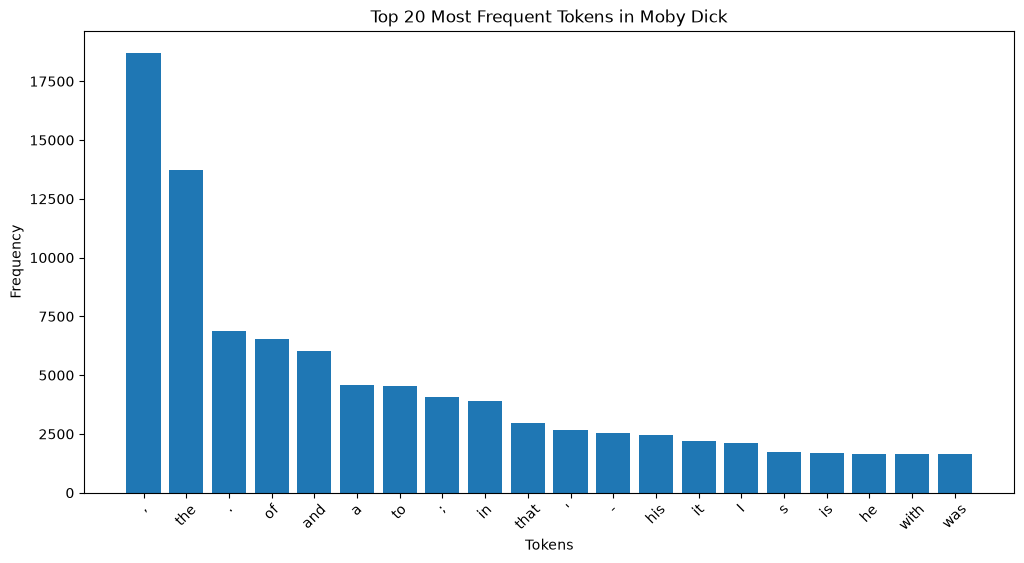

In [92]:
import matplotlib.pyplot as plt

# Get the 20 most common tokens
top_20 = dist.most_common(20)
tokens = [item[0] for item in top_20]
frequencies = [item[1] for item in top_20]

# Create a bar chart
plt.figure(figsize=(12, 6))
plt.bar(tokens, frequencies)
plt.title("Top 20 Most Frequent Tokens in Moby Dick")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

#### TF/IDF

In [93]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Example documents
doc1 = "Data Science is fascinating and fun."
doc2 = "Data analysis is a part of Data Science."
corpus = [doc1, doc2]

# Create the TF-IDF vectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)

# Show the feature names and the resulting vectors
print("Feature Names:", vectorizer.get_feature_names_out())
print("TF-IDF Vectors:\\n", X.toarray())

Feature Names: ['analysis' 'and' 'data' 'fascinating' 'fun' 'is' 'of' 'part' 'science']
TF-IDF Vectors:\n [[0.         0.47042643 0.33471228 0.47042643 0.47042643 0.33471228
  0.         0.         0.33471228]
 [0.40697968 0.         0.57913879 0.         0.         0.2895694
  0.40697968 0.40697968 0.2895694 ]]


<font color = green >

### 1.2. Access the NLTK corpora

   
</font>



<font color = green >

#### Determining the nltk_data location

</font>

import nltk
<br>
print (nltk.\_\_file\_\_) 
<br>
in that directory in the `data.py` you may see the path to your nltk_data


In [94]:
from pathlib import Path
import re

# Cross-platform way to find nltk/data.py on Windows, macOS, and Linux.
nltk_package_dir = Path(nltk.__file__).resolve().parent
fp = nltk_package_dir / "data.py"
print(fp)

with open(fp, "r", encoding="utf-8") as f:
    content = f.read()

match = re.search(r"NLTK data package might reside(?:.|\s){,260}", content)
if match:
    print(match.group(0))
else:
    print("NLTK data search paths:")
    for path in nltk.data.path:
        print(path)

C:\Users\User\Desktop\lesson_24_nltk_hometask\.venv\Lib\site-packages\nltk\data.py
NLTK data package might reside.
   These directories will be checked in order when looking for a
   resource in the data package.  Note that this allows users to
   substitute in their own versions of resources, if they have them
   (e.g., in their home directory under ~/nltk_data)."""

# 


<font color = green >

#### Review NLTK corpora

</font>


In [95]:
from pathlib import Path

# The original lecture path `/home/pc/nltk_data/corpora` is Linux-specific.
# Here we inspect the actual NLTK corpora folders available on this computer.
corpora_dirs = [
    Path(path) / "corpora"
    for path in nltk.data.path
    if (Path(path) / "corpora").exists()
]

if corpora_dirs:
    target_directory = corpora_dirs[0]
    print("Target corpora directory:", target_directory)
    print([str(Path(root).relative_to(target_directory)) for root, _, _ in os.walk(target_directory)])
else:
    print("No local corpora directory found yet. Run nltk.download(...) cells first.")

Target corpora directory: C:\Users\User\AppData\Roaming\nltk_data\corpora
['.', 'gutenberg', 'movie_reviews', 'movie_reviews\\neg', 'movie_reviews\\pos', 'state_union', 'stopwords', 'words']


<font color = green >

### 1.4. Words corpus 

</font>


In [96]:
nltk.download('words')


[nltk_data] Downloading package words to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [97]:
from nltk.corpus import words
correct_spellings = words.words()
print (correct_spellings[:100])

['A', 'a', 'aa', 'aal', 'aalii', 'aam', 'Aani', 'aardvark', 'aardwolf', 'Aaron', 'Aaronic', 'Aaronical', 'Aaronite', 'Aaronitic', 'Aaru', 'Ab', 'aba', 'Ababdeh', 'Ababua', 'abac', 'abaca', 'abacate', 'abacay', 'abacinate', 'abacination', 'abaciscus', 'abacist', 'aback', 'abactinal', 'abactinally', 'abaction', 'abactor', 'abaculus', 'abacus', 'Abadite', 'abaff', 'abaft', 'abaisance', 'abaiser', 'abaissed', 'abalienate', 'abalienation', 'abalone', 'Abama', 'abampere', 'abandon', 'abandonable', 'abandoned', 'abandonedly', 'abandonee', 'abandoner', 'abandonment', 'Abanic', 'Abantes', 'abaptiston', 'Abarambo', 'Abaris', 'abarthrosis', 'abarticular', 'abarticulation', 'abas', 'abase', 'abased', 'abasedly', 'abasedness', 'abasement', 'abaser', 'Abasgi', 'abash', 'abashed', 'abashedly', 'abashedness', 'abashless', 'abashlessly', 'abashment', 'abasia', 'abasic', 'abask', 'Abassin', 'abastardize', 'abatable', 'abate', 'abatement', 'abater', 'abatis', 'abatised', 'abaton', 'abator', 'abattoir', '

<font color = green >

## 2. Simple NLP Tasks 

</font>


<font color = green >

### 2.1. Tokenize

</font>



<font color = green >

#### Custom Tokenizer

</font>


In [98]:
import re
# This was used for parcing keywords for tokens 
def tokenize_sentence(target_str):
    target_str = re.sub(r"[_-]", ' ', target_str) # to get single tokens and apply the n-grams later 
    re_pattern = r"[\w\']+" 
    tokens = re.findall(re_pattern, target_str)
    return [token for token in tokens if len(token) > 2] 
tokenize_sentence("I like Ternopil. I don't care of Ivano-Frankivs'k" )

['like', 'Ternopil', "don't", 'care', 'Ivano', "Frankivs'k"]


<font color = green >

#### NLTK sentence tokenizer

</font>

sent_tokenize()

In [99]:
from nltk.tokenize import sent_tokenize
target_text= '''Hello Mr. Smith! How are you doing today? The whether is great and the Python is awesome. The sky is blue. The pen costs $2.45. What about pensil? Is ... the same price? '''
print (target_text)
sent_tokenize(target_text)

Hello Mr. Smith! How are you doing today? The whether is great and the Python is awesome. The sky is blue. The pen costs $2.45. What about pensil? Is ... the same price? 


['Hello Mr. Smith!',
 'How are you doing today?',
 'The whether is great and the Python is awesome.',
 'The sky is blue.',
 'The pen costs $2.45.',
 'What about pensil?',
 'Is ... the same price?']

<font color = green >

#### NLTK word tokenizer

</font>

word_tokenize()

In [100]:
from nltk.tokenize import word_tokenize
target_text= '''Hello Mr. Smith! How are you doing today? The whether is great and the Python is awesome. The sky is blue.'''
print (target_text)
print (word_tokenize(target_text))

Hello Mr. Smith! How are you doing today? The whether is great and the Python is awesome. The sky is blue.
['Hello', 'Mr.', 'Smith', '!', 'How', 'are', 'you', 'doing', 'today', '?', 'The', 'whether', 'is', 'great', 'and', 'the', 'Python', 'is', 'awesome', '.', 'The', 'sky', 'is', 'blue', '.']


<font color = green >

### 2.2. Stop words

</font>

stopwords()

In [101]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [102]:
from nltk.corpus import stopwords
stop_words= set(stopwords.words('english'))
# stop_words= set(stopwords.words('russian'))
print ('Total len : {}'.format(len(list(stop_words))))
print(list(stop_words)[:50])


Total len : 198
['same', "she's", 'at', 'no', 'wouldn', "should've", 'each', 's', "wouldn't", 'are', 'do', 'but', "that'll", 'your', 'weren', "it's", "you'd", "we'd", 'out', 'how', 'that', 'doing', 'all', 'yourselves', 'doesn', 'hasn', 'after', 'a', 'm', 'my', 'theirs', "wasn't", 't', "he'd", "i've", 'couldn', 'wasn', 'once', "we'll", 'the', "you've", "mustn't", "you're", 'don', 'other', 'haven', 'so', 'very', "they're", 'off']


In [103]:
target_text = 'This is an example showing the stop words filtering. Hello Mr. Smith! How are you doing today? The whether is great and the Python is awesome. The sky is blue.'
tokens = word_tokenize(target_text)
filtered_tokens= [t for t in tokens if t not in stop_words]

print (filtered_tokens)
print ('\nExcluded tokens (stopwords): \n{}'.format([t for t in tokens if t in stop_words]))


['This', 'example', 'showing', 'stop', 'words', 'filtering', '.', 'Hello', 'Mr.', 'Smith', '!', 'How', 'today', '?', 'The', 'whether', 'great', 'Python', 'awesome', '.', 'The', 'sky', 'blue', '.']

Excluded tokens (stopwords): 
['is', 'an', 'the', 'are', 'you', 'doing', 'is', 'and', 'the', 'is', 'is']


<font color = green >

### 2.3. Stemming 

</font>

PorterStemmer

In [104]:
from nltk.stem import PorterStemmer
from nltk.tokenize import  word_tokenize
import numpy as np

target_text = 'This is an example showing the stop words filtering. Hello Mr. Smith! How are you doing today? The whether is great and the Python is awesome. The sky is blue '

words= np.array(word_tokenize(target_text))
ps= PorterStemmer()
v_stem= np.vectorize(ps.stem)
stemmed_words= v_stem(words)

print (target_text)
stemmed_words


This is an example showing the stop words filtering. Hello Mr. Smith! How are you doing today? The whether is great and the Python is awesome. The sky is blue 


array(['thi', 'is', 'an', 'exampl', 'show', 'the', 'stop', 'word',
       'filter', '.', 'hello', 'mr.', 'smith', '!', 'how', 'are', 'you',
       'do', 'today', '?', 'the', 'whether', 'is', 'great', 'and', 'the',
       'python', 'is', 'awesom', '.', 'the', 'sky', 'is', 'blue'],
      dtype='<U7')

In [105]:
# one more sample
target_text = 'go, went, gone, going, gonna, goes, goings'
words= np.array(word_tokenize(target_text))
v_stem(words)

array(['go', ',', 'went', ',', 'gone', ',', 'go', ',', 'gon', 'na', ',',
       'goe', ',', 'go'], dtype='<U4')

In [106]:
# another sample ) 
target_text = 'apply, applied, applies, applying , applyings'
words= np.array(word_tokenize(target_text))
v_stem(words)

array(['appli', ',', 'appli', ',', 'appli', ',', 'appli', ',', 'appli'],
      dtype='<U5')

<font color = green >

### 2.3. Lemmatizing

</font>

WordNetLemmatizer

<font color = green >

#### Without specified POS  

</font>
noun by default 

In [107]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [108]:
from nltk.corpus import wordnet as wn
from nltk.stem import WordNetLemmatizer
wn_lemmatizer= WordNetLemmatizer()

In [109]:
[wn_lemmatizer.lemmatize(w) for w in word_tokenize(target_text)] # v - means verb

['apply', ',', 'applied', ',', 'applies', ',', 'applying', ',', 'applyings']

In [110]:
# sampl w/o pos tag 
target_text = 'is, am, are, was, were, been, being'
print([wn_lemmatizer.lemmatize(w) for w in word_tokenize(target_text)] )

['is', ',', 'am', ',', 'are', ',', 'wa', ',', 'were', ',', 'been', ',', 'being']


<font color = green >

#### With specified POS (part of speech) 

</font>
requesting lemmatizing to verb 

In [111]:
print (target_text)
[wn_lemmatizer.lemmatize(w,'v') for w in word_tokenize(target_text)] # v - means verb # the same as the following:
# [wn_lemmatizer.lemmatize(w,wn.VERB) for w in word_tokenize(target_text)] 

is, am, are, was, were, been, being


['be', ',', 'be', ',', 'be', ',', 'be', ',', 'be', ',', 'be', ',', 'be']

<font color = green >

#### With specified POS  

</font>
requesting lemmatizing to noun 

In [112]:
target_text = 'car, cars' 
[wn_lemmatizer.lemmatize(w,wn.NOUN) for w in word_tokenize(target_text)] 

['car', ',', 'car']

<font color = green >

### 2.4. Part of Speech (POS)

</font>

pos_tag()

In [113]:
nltk.download('state_union')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package state_union to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package state_union is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [114]:

from nltk.corpus import state_union
train_text= state_union.raw('2005-GWBush.txt')

In [115]:
print (train_text[:500])

PRESIDENT GEORGE W. BUSH'S ADDRESS BEFORE A JOINT SESSION OF THE CONGRESS ON THE STATE OF THE UNION
 
February 2, 2005


9:10 P.M. EST 

THE PRESIDENT: Mr. Speaker, Vice President Cheney, members of Congress, fellow citizens: 

As a new Congress gathers, all of us in the elected branches of government share a great privilege: We've been placed in office by the votes of the people we serve. And tonight that is a privilege we share with newly-elected leaders of Afghanistan, the Palestinian Territo


In [116]:
sentences = sent_tokenize(train_text)
s = sentences [10]
s

'Over the next several months, on issue after issue, let us do what Americans have always done, and build a better world for our children and our grandchildren.'

In [117]:
words= word_tokenize(s)
print ('words:\n{}'.format(words))
tagged= nltk.pos_tag(words)
print ('\ntags:\n{}'.format (tagged))


words:
['Over', 'the', 'next', 'several', 'months', ',', 'on', 'issue', 'after', 'issue', ',', 'let', 'us', 'do', 'what', 'Americans', 'have', 'always', 'done', ',', 'and', 'build', 'a', 'better', 'world', 'for', 'our', 'children', 'and', 'our', 'grandchildren', '.']

tags:
[('Over', 'IN'), ('the', 'DT'), ('next', 'JJ'), ('several', 'JJ'), ('months', 'NNS'), (',', ','), ('on', 'IN'), ('issue', 'NN'), ('after', 'IN'), ('issue', 'NN'), (',', ','), ('let', 'VB'), ('us', 'PRP'), ('do', 'VB'), ('what', 'WP'), ('Americans', 'NNPS'), ('have', 'VBP'), ('always', 'RB'), ('done', 'VBN'), (',', ','), ('and', 'CC'), ('build', 'VB'), ('a', 'DT'), ('better', 'JJR'), ('world', 'NN'), ('for', 'IN'), ('our', 'PRP$'), ('children', 'NNS'), ('and', 'CC'), ('our', 'PRP$'), ('grandchildren', 'NNS'), ('.', '.')]


<font color = green >

#### Review NLTK POS

</font>



In [118]:
nltk.download('tagsets')

[nltk_data] Downloading package tagsets to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package tagsets is already up-to-date!


True

In [119]:
nltk.help.upenn_tagset()

$: dollar
    $ -$ --$ A$ C$ HK$ M$ NZ$ S$ U.S.$ US$
'': closing quotation mark
    ' ''
(: opening parenthesis
    ( [ {
): closing parenthesis
    ) ] }
,: comma
    ,
--: dash
    --
.: sentence terminator
    . ! ?
:: colon or ellipsis
    : ; ...
CC: conjunction, coordinating
    & 'n and both but either et for less minus neither nor or plus so
    therefore times v. versus vs. whether yet
CD: numeral, cardinal
    mid-1890 nine-thirty forty-two one-tenth ten million 0.5 one forty-
    seven 1987 twenty '79 zero two 78-degrees eighty-four IX '60s .025
    fifteen 271,124 dozen quintillion DM2,000 ...
DT: determiner
    all an another any both del each either every half la many much nary
    neither no some such that the them these this those
EX: existential there
    there
FW: foreign word
    gemeinschaft hund ich jeux habeas Haementeria Herr K'ang-si vous
    lutihaw alai je jour objets salutaris fille quibusdam pas trop Monte
    terram fiche oui corporis ...
IN: preposition or

<font color = green >

#### Ambiguity of NLTK POS tagging 

</font>
NLTK tags the only one the most probable of possible cases


In [120]:
s = 'visiting friends can be surprising'
tagged = nltk.pos_tag(nltk.word_tokenize(s)) # alternative possible case [('visiting', 'JJ'),...] # friends is the subject
tagged # visiting is the subject

[('visiting', 'VBG'),
 ('friends', 'NNS'),
 ('can', 'MD'),
 ('be', 'VB'),
 ('surprising', 'JJ')]

<font color = green >

#### Converting POS formats 

</font>


In [121]:
def penn_to_wn(treebank_tag):
    if treebank_tag.startswith('J'):
        return wn.ADJ
    elif treebank_tag.startswith('V'):
        return wn.VERB
    elif treebank_tag.startswith('N'):
        return wn.NOUN
    elif treebank_tag.startswith('R'):
        return wn.ADV
    else:
        return ''

# def penn_to_wn(tag):
#     return get_wordnet_pos(tag)


{t[0]: penn_to_wn(t[1]) for t in tagged }

# Part-of-speech constants
#  ADJ, ADJ_SAT, ADV, NOUN, VERB = 'a', 's', 'r', 'n', 'v'

{'visiting': 'v', 'friends': 'n', 'can': '', 'be': 'v', 'surprising': 'a'}

In [122]:
# Mention about 
# 1) pos used in recognizing location 
# 2) pos used in language model to predict placeholders

<font color = green >

#### Chunks of POS

</font>

RegexpParser()

In [123]:
%matplotlib inline

In [124]:
import nltk 
from nltk.corpus import state_union
from nltk.tokenize import sent_tokenize, word_tokenize
train_text= state_union.raw('2005-GWBush.txt')


In [125]:
nltk.download('maxent_ne_chunker')

[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!


True

In [126]:

sentences = sent_tokenize(train_text)

for s in sentences[13:15]:
    print('='*40, '\nsentence= {}'.format(s))
    words= word_tokenize(s)
    # print ('words= {}'.format(words))
    tagged= nltk.pos_tag(words) # part of speech (POS)  # works for list of words
    print('\ntagged:\n{}'.format(tagged))

    # detect chunks 
    chunk_gram = 'chunk: {<JJ.?>+<NN.?>+} ' # selects adj and noun followed by
    
    chunk_parser = nltk.RegexpParser(chunk_gram)
    chunked = chunk_parser.parse(tagged)    
    print('\nchunked:\n{}'.format(chunked.flatten))

    # extract chunks 
    chunks = []
    for subtree in chunked.subtrees(filter=lambda t: t.label() == 'chunk'):
        chunk = ""
        for leaf in subtree.leaves():
            chunk += leaf[0] + ' '
        chunks.append(chunk.strip())

    print('\nDetected chunks:\n{}'.format(chunks))
    
#     draw tree 
#     chunked.draw()
    

sentence= America's economy is the fastest growing of any major industrialized nation.

tagged:
[('America', 'NNP'), ("'s", 'POS'), ('economy', 'NN'), ('is', 'VBZ'), ('the', 'DT'), ('fastest', 'JJS'), ('growing', 'NN'), ('of', 'IN'), ('any', 'DT'), ('major', 'JJ'), ('industrialized', 'VBN'), ('nation', 'NN'), ('.', '.')]

chunked:
<bound method Tree.flatten of Tree('S', [('America', 'NNP'), ("'s", 'POS'), ('economy', 'NN'), ('is', 'VBZ'), ('the', 'DT'), Tree('chunk', [('fastest', 'JJS'), ('growing', 'NN')]), ('of', 'IN'), ('any', 'DT'), ('major', 'JJ'), ('industrialized', 'VBN'), ('nation', 'NN'), ('.', '.')])>

Detected chunks:
['fastest growing']
sentence= In the past four years, we provided tax relief to every person who pays income taxes, overcome a recession, opened up new markets abroad, prosecuted corporate criminals, raised homeownership to its highest level in history, and in the last year alone, the United States has added 2.3 million new jobs.

tagged:
[('In', 'IN'), ('the',

### Sample of visualization 
due to issue with `chunked.draw()`

In [127]:

sentence = [("the", "DT"), ("little", "JJ"), ("yellow", "JJ"), ("dog", "NN"), ("barked", "VBD"), ("at", "IN"),  ("the", "DT"), ("cat", "NN")]
print ('Tagged:\n', sentence)
grammar = "NP: {<DT>?<JJ>*<NN>}" 

cp = nltk.RegexpParser(grammar) 
result = cp.parse(sentence)
print(result)
# result.draw()

Tagged:
 [('the', 'DT'), ('little', 'JJ'), ('yellow', 'JJ'), ('dog', 'NN'), ('barked', 'VBD'), ('at', 'IN'), ('the', 'DT'), ('cat', 'NN')]
(S
  (NP the/DT little/JJ yellow/JJ dog/NN)
  barked/VBD
  at/IN
  (NP the/DT cat/NN))


<img src = "chunks.png" height=500 width= 500 align="left">



In [128]:
from nltk.tree import Tree
s = 'Donald came to New York for summit'
words= word_tokenize(s)
tagged_words= nltk.pos_tag(words) # part of speech (POS)  # works for list of words
chunked= nltk.ne_chunk(tagged_words)
# print ('named_entities:\n{}'.format(chunked))

def extract_ne_chunks(chunked): 
    chunks = []
    for i in chunked:
        if type(i) == Tree:    
            print (i.flatten)
            chunks.append(" ".join([token for token, pos in i.leaves()]))
    return chunks


extract_ne_chunks(chunked)

# chunked.draw()

<bound method Tree.flatten of Tree('PERSON', [('Donald', 'NNP')])>
<bound method Tree.flatten of Tree('GPE', [('New', 'NNP'), ('York', 'NNP')])>


['Donald', 'New York']

<font color = green >

### 2.5. Wordnet

</font>



In [129]:
from nltk.corpus import wordnet as wn

<font color = green >

#### Synsets

</font>

wn.synsets()

In [130]:
target_word = 'look'
print('target_word = {} '.format(target_word))

synsets = wn.synsets(target_word)
print (synsets[0])
[synset.name() for  synset  in synsets]


target_word = look 
Synset('expression.n.01')


['expression.n.01',
 'look.n.02',
 'look.n.03',
 'spirit.n.02',
 'look.v.01',
 'look.v.02',
 'look.v.03',
 'search.v.02',
 'front.v.01',
 'attend.v.02',
 'look.v.07',
 'expect.v.03',
 'look.v.09',
 'count.v.08']

<font color = green >

#### Lemmas

</font>

synset.lemmas()

In [131]:
for synset in synsets:
    print ('{}:{}'.format(synset.name(), [lemma.name() for  lemma in synset.lemmas()]))

print ('\n',synsets[0].lemmas()[2])

expression.n.01:['expression', 'look', 'aspect', 'facial_expression', 'face']
look.n.02:['look', 'looking', 'looking_at']
look.n.03:['look']
spirit.n.02:['spirit', 'tone', 'feel', 'feeling', 'flavor', 'flavour', 'look', 'smell']
look.v.01:['look']
look.v.02:['look', 'appear', 'seem']
look.v.03:['look']
search.v.02:['search', 'look']
front.v.01:['front', 'look', 'face']
attend.v.02:['attend', 'take_care', 'look', 'see']
look.v.07:['look']
expect.v.03:['expect', 'look', 'await', 'wait']
look.v.09:['look']
count.v.08:['count', 'bet', 'depend', 'look', 'calculate', 'reckon']

 Lemma('expression.n.01.aspect')


<font color = green >

#### Definitions

</font>

synset.definition()

In [132]:
for synset in synsets:
    print ('{}:\t{}'.format(synset.name(), synset.definition()))

expression.n.01:	the feelings expressed on a person's face
look.n.02:	the act of directing the eyes toward something and perceiving it visually
look.n.03:	physical appearance
spirit.n.02:	the general atmosphere of a place or situation and the effect that it has on people
look.v.01:	perceive with attention; direct one's gaze towards
look.v.02:	give a certain impression or have a certain outward aspect
look.v.03:	have a certain outward or facial expression
search.v.02:	search or seek
front.v.01:	be oriented in a certain direction, often with respect to another reference point; be opposite to
attend.v.02:	take charge of or deal with
look.v.07:	convey by one's expression
expect.v.03:	look forward to the probable occurrence of
look.v.09:	accord in appearance with
count.v.08:	have faith or confidence in


<font color = green >

#### Examples

</font>
synset.examples()

In [133]:
for synset in synsets:
    print ('{}:\t{}\n'.format(synset.name(), synset.examples()))



expression.n.01:	['a sad expression', 'a look of triumph', 'an angry face']

look.n.02:	['he went out to have a look', 'his look was fixed on her eyes', 'he gave it a good looking at', 'his camera does his looking for him']

look.n.03:	["I don't like the looks of this place"]

spirit.n.02:	['the feel of the city excited him', 'a clergyman improved the tone of the meeting', 'it had the smell of treason']

look.v.01:	['She looked over the expanse of land', 'Look at your child!', 'Look--a deer in the backyard!']

look.v.02:	['She seems to be sleeping', 'This appears to be a very difficult problem', 'This project looks fishy', 'They appeared like people who had not eaten or slept for a long time']

look.v.03:	['How does she look?', 'The child looks unhappy', 'She looked pale after the surgery']

search.v.02:	['We looked all day and finally found the child in the forest', 'Look elsewhere for the perfect gift!']

front.v.01:	['The house looks north', 'My backyard look onto the pond', 'The bu

<font color = green >

#### Synonyms and Antonyms

</font>
synset.lemmas()
<br>lemma.antonyms()

In [134]:
def get_syn_ant(target_word):
    synonyms = []
    antonyms = []
    print('target_word = {} '.format(target_word))

    for syn in wn.synsets(target_word):
        for l in syn.lemmas(): # use lemmas to obtain synonyms
            synonyms.append(l.name())
            if l.antonyms():  # some lemmas have antonyms
                antonyms.append({la.name(): l.name() for la in l.antonyms()})
#                 antonyms.append(l.antonyms()[0].name())  # Assuming selecting just first antonym for lemma
    return set(synonyms), antonyms

target_word = 'good'
synonyms, antonyms =  get_syn_ant (target_word)
print ('\nsynonyms:', synonyms),
print ('antonyms:\n', antonyms)

target_word = good 

synonyms: {'serious', 'in_effect', 'undecomposed', 'skillful', 'respectable', 'just', 'dear', 'expert', 'full', 'beneficial', 'safe', 'right', 'sound', 'trade_good', 'upright', 'thoroughly', 'adept', 'unspoiled', 'skilful', 'honest', 'in_force', 'near', 'dependable', 'goodness', 'honorable', 'commodity', 'unspoilt', 'ripe', 'secure', 'effective', 'practiced', 'proficient', 'good', 'soundly', 'estimable', 'salutary', 'well'}
antonyms:
 [{'evil': 'good'}, {'evilness': 'goodness'}, {'bad': 'good'}, {'badness': 'goodness'}, {'bad': 'good'}, {'evil': 'good'}, {'ill': 'well'}]


In [135]:
words_pairs= [('drink.n.01', 'water.n.01'),
              ('drink.n.01', 'milk.n.01'),
              ('milk.n.01', 'water.n.01'),
              ('drink.n.01', 'coca_cola.n.01'),
              ('pepsi.n.01', 'coca_cola.n.01'),
              ('New_year.n.01', 'Santa_Claus.n.01'),
              ('New_year.n.01', 'christmas.n.01')
              ]
for words_pair in words_pairs:
    w1 = wn.synset(words_pair[0])
    w2 = wn.synset(words_pair[1])
    print('{}  vs {}: {}'.format(w1.name(), w2.name(), w1.wup_similarity(w2)))

drink.n.01  vs water.n.01: 0.26666666666666666
drink.n.01  vs milk.n.01: 0.25
milk.n.01  vs water.n.01: 0.42105263157894735
drink.n.01  vs coca_cola.n.01: 0.2222222222222222
pepsi.n.01  vs coca_cola.n.01: 0.9090909090909091
new_year.n.01  vs santa_claus.n.01: 0.25
new_year.n.01  vs christmas.n.01: 0.7142857142857143


<font color = green >

### 2.6. Edit Distance

</font>

nltk.edit_distance()

In [136]:
target_pairs= [
    ('hello', 'hell'),
    ('hell', 'hall'),
    ('men', 'manual'),
    ('Р В РЎВР РЋРЎвЂњР РЋРІР‚В¦Р В Р’В°', 'Р РЋР С“Р В Р’В»Р В РЎвЂўР В Р вЂ¦'),
    ('casual', 'causal'),
    ('top', 'pot'),
    ('top', 'open')
    
]
for word_1, word_2 in target_pairs:
    print ('{}, {}: {}/{}'.format(word_1, word_2, nltk.edit_distance(word_1, word_2,transpositions=True), 
                                 nltk.edit_distance(word_1, word_2,transpositions=False)))


hello, hell: 1/1
hell, hall: 1/1
men, manual: 4/4
Р В РЎВР РЋРЎвЂњР РЋРІР‚В¦Р В Р’В°, Р РЋР С“Р В Р’В»Р В РЎвЂўР В Р вЂ¦: 22/22
casual, causal: 1/2
top, pot: 2/2
top, open: 3/3


<font color = green >

### 2.7. Wordnet similarity

</font>



<font color = green >

#### Wordnet hierarchy

</font>
WordNet organizes information in a hierarchy 
Verbs, nouns, adjectives etc. all have separate hierarchy 


In [137]:
%%html
<img src = 'wn_tree1.png' height=500 width= 500 align="left">


<font color = green >

#### Path similarity

</font>

$1/(n+1)$ , $n$ - steps between concepts
<br>
synset_1.path_similarity(synset_2)

In [138]:
deer_synset = wn.synset('deer.n.01')
elk_synset=  wn.synset('elk.n.01')
horse_synset=  wn.synset('horse.n.01')
print ('{} and {}: {}'.format('deer','elk', deer_synset.path_similarity(elk_synset))) # d= 2 
print ('{} and {}: {}'.format('deer','horse', deer_synset.path_similarity(horse_synset))) # d= 7 

deer and elk: 0.5
deer and horse: 0.14285714285714285


<font color = green >

#### Wu-Palmer similarity

</font>
synset_1.wup_similarity(synset_2)


In [139]:
# comparing to wup_similarity
print ('{} and {}: {}'.format('deer','elk', deer_synset.wup_similarity(elk_synset)))  
print ('{} and {}: {}'.format('deer','horse', deer_synset.wup_similarity(horse_synset))) 

deer and elk: 0.967741935483871
deer and horse: 0.8


In [140]:
# import editdistance # standalone package

def calc_words_similarity(word_a,word_b, verbose= 0):
    ''' Calculates wup similarity for all synsets if synsets available, and score based on edit distance otherwise
        in case of synsets available returns max of all values
    '''
    word_a_synsets= wn.synsets(word_a)
    word_b_synsets= wn.synsets(word_b)
    if len (word_a_synsets)==0 or len (word_b_synsets)==0:
        if verbose: 
            print ('One of words has no synsets')
        return calc_edit_score(word_a,word_b)
    else:
        similarities_all_synsets= []
        for word_a_synset in word_a_synsets:
            for word_b_synset in word_b_synsets:
                if word_a_synset.pos() == word_b_synset.pos():  # this speeds up the calculation                   
                    synsets_similarity =  word_a_synset.wup_similarity(word_b_synset)
                    if synsets_similarity: # some time return None
                        similarities_all_synsets.append(synsets_similarity)
                    else: # synsets_similarity is None
                        synsets_similarity= 0 
                else: # different pos 
                    synsets_similarity= 0 
                similarities_all_synsets.append(synsets_similarity)
                if verbose:
                    print (word_a_synset.name(), word_b_synset.name(), synsets_similarity)
        return max(similarities_all_synsets)

def calc_edit_score(w1, w2):
    '''calc the score being based on edit (Levinshtein) distance
        1 difference - 0.8, 2- 0.64, 3-.51 ...
    '''
    edit_dist= nltk.edit_distance(w1, w2)    
    if edit_dist> len (w1) or edit_dist> len (w2): # no common letter
        print ('No common letter. Consider similarity as 0.')
        return 0
    return 0.8 ** edit_dist

calc_words_similarity('drink','pepsi', verbose= 1)
# calc_words_similarity('deer','horse', verbose= 1)


drink.n.01 pepsi.n.01 0.2222222222222222
drink.n.02 pepsi.n.01 0.18181818181818182
beverage.n.01 pepsi.n.01 0.8421052631578947
drink.n.04 pepsi.n.01 0.2857142857142857
swallow.n.02 pepsi.n.01 0.25
drink.v.01 pepsi.n.01 0
drink.v.02 pepsi.n.01 0
toast.v.02 pepsi.n.01 0
drink_in.v.01 pepsi.n.01 0
drink.v.05 pepsi.n.01 0


0.8421052631578947

<font color = green >

#### Custom phrase similarity

</font>


In [141]:
def calc_phrase_similarity(phrase_a, phrase_b):
    '''
    phrase_a, phrase_b - str
    '''
    if len (phrase_a) * len (phrase_b)== 0:
        return 0

    tokens_a = nltk.word_tokenize(phrase_a)
    tokens_a = [w for w in tokens_a if w not in stop_words]

    tokens_b = nltk.word_tokenize(phrase_b)
    tokens_b = [w for w in tokens_b if w not in stop_words]

    
    a_similarity =  target_phrase_avg(tokens_a, tokens_b)
    b_similarity =  target_phrase_avg(tokens_b, tokens_a)

    return np.mean([a_similarity, b_similarity])

def target_phrase_avg(tokens_a, tokens_b):
    all_similarities= [target_word_similarity_score(tokens_a, b) for b in tokens_b]
    if len(all_similarities)>0:
        return np.mean(all_similarities)
    else:
        return 0


def target_word_similarity_score(current_words, target_word):
    '''
    Calculates similarity between all current words (all synsets) and ONE target word (all synsets)
    :param current_words: list of words of current phrase
    :param target_word: str
    :return: float
    '''
    if len(current_words)==0:
        return 0
    all_current_words_similarities= []
    for current_word in current_words:
        all_current_words_similarities.append(calc_words_similarity(current_word, target_word))
    if len(all_current_words_similarities)==0:
        return 0
    return max(all_current_words_similarities)

phrase_a = 'Data Science is fascinating'
phrase_b = 'Work with data is interesting'

# phrase_a = 'Data Science is fascinating'
# phrase_b = 'the milk is white'

print ('{}\n{}'.format(phrase_a, phrase_b))
calc_phrase_similarity(phrase_a, phrase_b)

Data Science is fascinating
Work with data is interesting


np.float64(0.8634920634920635)

<font color = green >

## 3. Tying it all together 

</font>


In [142]:
import random
from nltk.corpus import movie_reviews

nltk.download('movie_reviews')

documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

random.shuffle(documents)

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


<font color = green >

#### Feature extraction

</font>


In [143]:
# Get the 2000 most frequent words from the corpus
all_words = nltk.FreqDist(w.lower() for w in movie_reviews.words())
word_features = list(all_words)[:2000]

def find_features(document):
    words = set(document)
    features = {}
    for w in word_features:
        features[w] = (w in words)
    return features

# Example of the boolean feature representation used for POS/NEG classification.
sample_features = {
    "some": True,
    "bad": False,
    "luck": True,
}
sample_features

{'some': True, 'bad': False, 'luck': True}

<font color = green >

#### Train classifier

</font>


In [144]:
# Create feature sets for all our documents
featuresets = [(find_features(rev), category) for (rev, category) in documents]

# Split data into training and testing sets
training_set = featuresets[:1600]
testing_set = featuresets[1600:]

# Train the classifier
classifier = nltk.NaiveBayesClassifier.train(training_set)

<font color = green >

#### Evaluate accuracy

</font>


In [145]:
# Check accuracy
accuracy = nltk.classify.accuracy(classifier, testing_set)
print(f"Classifier accuracy: {accuracy*100:.2f}%")

# Show the most informative features
classifier.show_most_informative_features(15)

Classifier accuracy: 81.00%
Most Informative Features
             outstanding = True              pos : neg    =      9.2 : 1.0
             wonderfully = True              pos : neg    =      8.4 : 1.0
                  seagal = True              neg : pos    =      8.3 : 1.0
                   mulan = True              pos : neg    =      8.2 : 1.0
                  wasted = True              neg : pos    =      6.9 : 1.0
                    lame = True              neg : pos    =      5.7 : 1.0
                   awful = True              neg : pos    =      5.6 : 1.0
                   damon = True              pos : neg    =      5.5 : 1.0
                     era = True              pos : neg    =      5.3 : 1.0
                   waste = True              neg : pos    =      4.9 : 1.0
                   bland = True              neg : pos    =      4.8 : 1.0
                  poorly = True              neg : pos    =      4.8 : 1.0
                  superb = True              p

<font color = green >

## Home Task 

</font>


In [146]:
import nltk
import numpy as np
from nltk import FreqDist
from nltk.corpus import gutenberg, words
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize, word_tokenize

# Resources required for the homework cells. `quiet=True` keeps the notebook output clean.
for package in [
    "gutenberg",
    "punkt",
    "punkt_tab",
    "wordnet",
    "words",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
]:
    nltk.download(package, quiet=True)

In [147]:
moby_raw = gutenberg.raw("melville-moby_dick.txt")

moby_tokens = word_tokenize(moby_raw)
moby_sentences = sent_tokenize(moby_raw)
moby_dist = FreqDist(moby_tokens)

<font color = green >

### Example 1

</font>

How many tokens (words and punctuation symbols) are in `moby_raw`?
<br>*This function should return an integer.*

In [148]:
def example_one():
    from nltk.tokenize import word_tokenize
    return len(word_tokenize(moby_raw)) 

<font color = blue >

### Check result

</font>


In [149]:
print ('{:,}'.format(example_one()))

255,028


<font color = green >

### Example 2

</font>

How many unique tokens (unique words and punctuation) does `moby_raw` have?
<br>*This function should return an integer.*

In [150]:
def example_two():    
    return len(set(nltk.word_tokenize(moby_raw)))

<font color = blue >

### Check result

</font>


In [151]:
print ('{:,}'.format(example_two()))

20,742


<font color = green >

### Example 3

</font>

After lemmatizing the verbs, how many unique tokens does `moby_raw` have?
<br>*This function should return an integer.*


In [152]:
from nltk.stem import WordNetLemmatizer

def example_three():
    lemmatizer = WordNetLemmatizer()
    lemmatized = [lemmatizer.lemmatize(w,'v') for w in nltk.word_tokenize(moby_raw)]
    return len(set(lemmatized))

<font color = blue >

### Check result

</font>


In [153]:
print ('{:,}'.format(example_three()))

16,887


<font color = green >

### Question 1

</font>


What is the lexical diversity of the given text input? (i.e. ratio of unique tokens to the total number of tokens)
<br>*This function should return a float.*


In [154]:
def answer_one():
    return len(set(moby_tokens)) / len(moby_tokens)

<font color = blue >

### Check result

</font>


In [155]:
answer_one()

0.08133224587104161

<font color = blue >

### Expected Output

</font>

`0.08139566804842562`


<font color = green >

### Question 2

</font>

What percentage of tokens is 'whale'or 'Whale'?
<br>*This function should return a float.*

In [156]:
from nltk.tokenize import word_tokenize

def answer_two():
    whale_count = moby_tokens.count("whale") + moby_tokens.count("Whale")
    return whale_count / len(moby_tokens) * 100

<font color = blue >

### Check result

</font>


In [157]:
answer_two()

0.4125037250811676

<font color = blue >

### Expected Output

</font>

`0.4125668166077752`


<font color = green >

### Question 3

</font>

What are the 20 most frequently occurring (unique) tokens in the text? What is their frequency?
<br>*This function should return a list of 10 tuples where each tuple is of the form `(token, frequency)`. The list should be sorted in descending order of frequency.*

In [158]:
def answer_three():
    # The task text mentions 20 tokens, but the expected output contains the top 10.
    return moby_dist.most_common(10)

<font color = blue >

### Check result

</font>


In [159]:
answer_three()

[(',', 19204),
 ('the', 13715),
 ('.', 7306),
 ('of', 6513),
 ('and', 6010),
 ('a', 4545),
 ('to', 4515),
 (';', 4173),
 ('in', 3908),
 ('that', 2978)]

<font color = blue >

### Expected Output

</font>

`[(',', 19204),
 ('the', 13715),
 ('.', 7308),
 ('of', 6513),
 ('and', 6010),
 ('a', 4545),
 ('to', 4515),
 (';', 4173),
 ('in', 3908),
 ('that', 2978)]`


<font color = green >

### Question 4

</font>

What tokens have a length of greater than 5 and frequency of more than 150?
<br>*This function should return a sorted list of the tokens that match the above constraints. To sort your list, use `sorted()`*

In [160]:
def answer_four():
    return sorted([
        token
        for token, frequency in moby_dist.items()
        if len(token) > 5 and frequency > 150
    ])

<font color = blue >

### Check result

</font>


In [161]:
print (answer_four())

['Captain', 'Pequod', 'Queequeg', 'Starbuck', 'almost', 'before', 'himself', 'little', 'seemed', 'should', 'though', 'through', 'whales', 'without']


<font color = blue >

### Expected Output

</font>

`['Captain', 'Pequod', 'Queequeg', 'Starbuck', 'almost', 'before', 'himself', 'little', 'seemed', 'should', 'though', 'through', 'whales', 'without']`


<font color = green >

### Question 5

</font>

Find the longest word in text1 and that word's length.
<br>
*This function should return a tuple `(longest_word, length)`.*


In [162]:
def answer_five():
    longest_word = max(moby_tokens, key=len)
    return longest_word, len(longest_word)

<font color = blue >

### Check result

</font>


In [163]:
answer_five()

("twelve-o'clock-at-night", 23)

<font color = blue >

### Expected Output

</font>

`("twelve-o'clock-at-night", 23)`


<font color = green >

### Question 6

</font>

What unique words have a frequency of more than 2000? What is their frequency?
<br>*This function should return a list of tuples of the form `(frequency, word)` sorted in descending order of frequency.*


In [164]:
def answer_six():
    return sorted(
        [
            (frequency, token)
            for token, frequency in moby_dist.items()
            if token.isalpha() and frequency > 2000
        ],
        reverse=True,
    )

<font color = blue >

### Check result

</font>


In [165]:
print(answer_six())

[(13715, 'the'), (6513, 'of'), (6010, 'and'), (4545, 'a'), (4515, 'to'), (3908, 'in'), (2978, 'that'), (2459, 'his'), (2196, 'it'), (2113, 'I')]


<font color = blue >

### Expected Output

</font>

`[(13715, 'the'), (6513, 'of'), (6010, 'and'), (4545, 'a'), (4515, 'to'), (3908, 'in'), (2978, 'that'), (2459, 'his'), (2196, 'it'), (2097, 'I')]`


<font color = green >

### Question 7

</font>

What is the average number of tokens per sentence?
<br>*This function should return a float.*

In [166]:
from nltk.tokenize import sent_tokenize,word_tokenize
import numpy as np 

In [167]:
def answer_seven():
    sentence_lengths = [len(word_tokenize(sentence)) for sentence in moby_sentences]
    return float(np.mean(sentence_lengths))

<font color = blue >

### Check result

</font>


In [168]:
print(answer_seven())

25.88591149005278


<font color = blue >

### Expected Output

</font>

`25.881952902963864`


<font color = green >

### Question 8

</font>

What are the 5 most frequent parts of speech in this text? What is their frequency?
<br>*This function should return a list of tuples of the form `(part_of_speech, frequency)` sorted in descending order of frequency.*

In [169]:
def answer_eight():
    tagged_tokens = nltk.pos_tag(moby_tokens)
    tag_distribution = FreqDist(tag for _, tag in tagged_tokens)
    return tag_distribution.most_common(5)

<font color = blue >

### Check result

</font>


In [170]:
print(answer_eight())

[('NN', 32727), ('IN', 28662), ('DT', 25879), (',', 19204), ('JJ', 17613)]


<font color = blue >

### Expected Output

</font>

`[('NN', 32730), ('IN', 28657), ('DT', 25867), (',', 19204), ('JJ', 17620)]`


<font color = green >

### Question 9

</font>

Create spelling recommender, that take a list of misspelled words and recommends a correctly spelled word for every word in the list.

For every misspelled word, the recommender should find find the word in `correct_spellings` that has the shortest `edit distance` (you may need  to use `nltk.edit_distance(word_1, word_2, transpositions=True)`), and starts with the same letter as the misspelled word, and return that word as a recommendation.

Recommender should provide recommendations for the three words: `['cormulent', 'incendenece', 'validrate']`.
<br>*This function should return a list of length three:
`['cormulent_reccomendation', 'incendenece_reccomendation', 'validrate_reccomendation']`.*

In [171]:
from nltk.corpus import words

In [172]:
def answer_nine(default_words=["cormulent", "incendenece", "validrate"]):
    correct_spellings = words.words()
    recommendations = []

    for misspelled_word in default_words:
        same_first_letter = [
            word
            for word in correct_spellings
            if word.startswith(misspelled_word[0])
        ]
        recommendation = min(
            same_first_letter,
            key=lambda word: (
                nltk.edit_distance(misspelled_word, word, transpositions=True),
                word,
            ),
        )
        recommendations.append(recommendation)

    return recommendations

<font color = blue >

### Check result

</font>


In [173]:
answer_nine()

['corpulent', 'intendence', 'validate']

<font color = blue >

### Expected Output

</font>

`['corpulent', 'intendence', 'validate']`